In [12]:
import pandas as pd
import numpy as np

# Text preprocessing
import re
import string
import nltk
nltk.download('punkt_tab')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Train test split
from sklearn.model_selection import train_test_split

# Naive Bayes
from sklearn.naive_bayes import MultinomialNB

# Evaluation metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Sentiment Analysis
from textblob import TextBlob

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Download nltk resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [13]:
# Load dataset

df = pd.read_csv("/content/blogs.csv")

# Display first 5 rows
df.head()

,Data,Labels
0,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism
1,Newsgroups: alt.atheism\nPath: cantaloupe.srv....,alt.atheism
2,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,alt.atheism
3,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism
4,Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...,alt.atheism


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Data    2000 non-null   object
 1   Labels  2000 non-null   object
dtypes: object(2)
memory usage: 31.4+ KB


In [15]:
df.describe()

,Data,Labels
count,2000,2000
unique,2000,20
top,Xref: cantaloupe.srv.cs.cmu.edu talk.religion....,alt.atheism
freq,1,100


In [16]:
df.shape

(2000, 2)

In [17]:
df.columns

Index(['Data', 'Labels'], dtype='object')

In [18]:
# Stopwords
stop_words = set(stopwords.words('english'))

# Text cleaning function
def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # Join words
    text = " ".join(tokens)

    return text

# Apply cleaning
df['Cleaned_Text'] = df['Data'].astype(str).apply(clean_text)

# Display cleaned text
df[['Data', 'Cleaned_Text']].head()

,Data,Cleaned_Text
0,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,path cantaloupesrvcscmuedumagnesiumclubcccmued...
1,Newsgroups: alt.atheism\nPath: cantaloupe.srv....,newsgroups altatheism path cantaloupesrvcscmue...
2,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,path cantaloupesrvcscmuedudasnewsharvardedunoc...
3,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,path cantaloupesrvcscmuedumagnesiumclubcccmued...
4,Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...,xref cantaloupesrvcscmuedu altatheism talkreli...


In [19]:
# TF-IDF Vectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['Cleaned_Text'])

# Target variable
y = df['Labels']

print("Feature Shape:", X.shape)

Feature Shape: (2000, 5000)


In [20]:
# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Size:", X_train.shape)
print("Testing Size:", X_test.shape)

Training Size: (1600, 5000)
Testing Size: (400, 5000)


In [21]:
# Initialize model

nb_model = MultinomialNB()

# Train model
nb_model.fit(X_train, y_train)

# Predictions
y_pred = nb_model.predict(X_test)

In [22]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

# Classification report
print(classification_report(y_test, y_pred))

Accuracy: 0.8425
                          precision    recall  f1-score   support

             alt.atheism       0.50      0.83      0.62        18
           comp.graphics       0.73      0.89      0.80        18
 comp.os.ms-windows.misc       0.91      0.95      0.93        22
comp.sys.ibm.pc.hardware       0.83      0.80      0.82        25
   comp.sys.mac.hardware       0.86      0.90      0.88        21
          comp.windows.x       0.95      0.84      0.89        25
            misc.forsale       1.00      0.78      0.88        18
               rec.autos       0.90      1.00      0.95        18
         rec.motorcycles       1.00      0.94      0.97        16
      rec.sport.baseball       0.84      0.89      0.86        18
        rec.sport.hockey       0.88      1.00      0.94        15
               sci.crypt       0.90      1.00      0.95        19
         sci.electronics       0.67      0.75      0.71        16
                 sci.med       0.88      0.88      0.88   

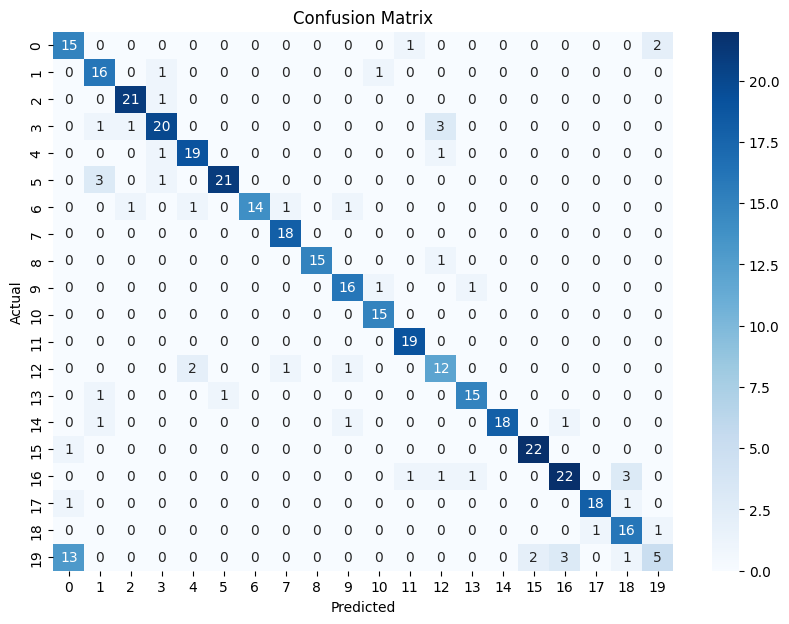

In [23]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,7))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [24]:
# Function for sentiment analysis

def get_sentiment(text):

    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0:
        return "Positive"

    elif polarity < 0:
        return "Negative"

    else:
        return "Neutral"

# Apply sentiment analysis
df['Sentiment'] = df['Data'].astype(str).apply(get_sentiment)

# Display sentiments
df[['Data', 'Sentiment']].head()

,Data,Sentiment
0,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,Positive
1,Newsgroups: alt.atheism\nPath: cantaloupe.srv....,Negative
2,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,Positive
3,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,Positive
4,Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...,Positive


Sentiment
Positive    1543
Negative     457
Name: count, dtype: int64


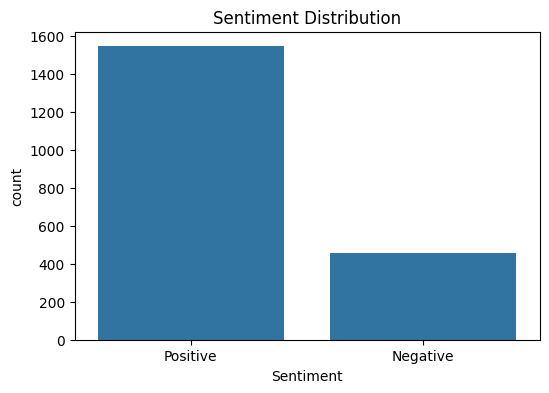

In [25]:
# Sentiment counts

print(df['Sentiment'].value_counts())

# Plot sentiment distribution

plt.figure(figsize=(6,4))

sns.countplot(x=df['Sentiment'])

plt.title("Sentiment Distribution")

plt.show()

Sentiment                 Negative  Positive
Labels                                      
alt.atheism                     23        77
comp.graphics                   24        76
comp.os.ms-windows.misc         22        78
comp.sys.ibm.pc.hardware        20        80
comp.sys.mac.hardware           24        76
comp.windows.x                  27        73
misc.forsale                    16        84
rec.autos                       17        83
rec.motorcycles                 26        74
rec.sport.baseball              29        71
rec.sport.hockey                34        66
sci.crypt                       19        81
sci.electronics                 19        81
sci.med                         29        71
sci.space                       27        73
soc.religion.christian          13        87
talk.politics.guns              30        70
talk.politics.mideast           22        78
talk.politics.misc              22        78
talk.religion.misc              14        86


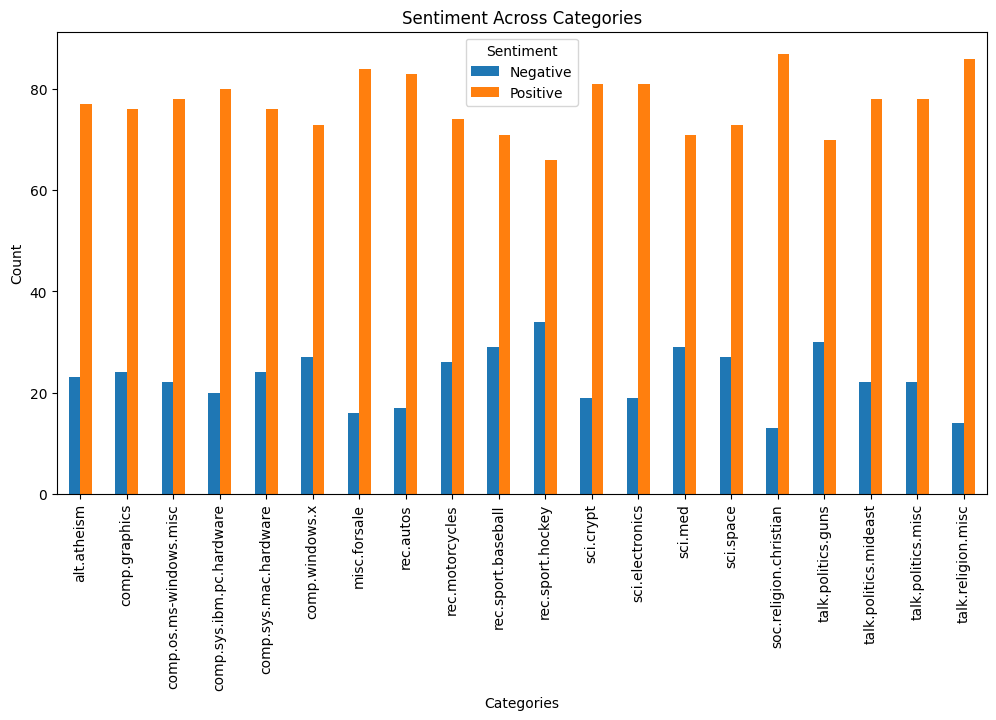

In [26]:
# Crosstab

sentiment_category = pd.crosstab(df['Labels'], df['Sentiment'])

print(sentiment_category)

# Plot

sentiment_category.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Sentiment Across Categories")
plt.xlabel("Categories")
plt.ylabel("Count")

plt.show()

In [27]:
# Sample predictions

sample_text = [
    "Machine learning is transforming industries rapidly",
    "I hate the poor service and bad experience",
    "The blog content was average and informative"
]

# Clean text
sample_clean = [clean_text(text) for text in sample_text]

# TF-IDF transform
sample_vector = tfidf.transform(sample_clean)

# Predict category
predictions = nb_model.predict(sample_vector)

# Display results
for text, pred in zip(sample_text, predictions):
    print("Text:", text)
    print("Predicted Category:", pred)
    print()

Text: Machine learning is transforming industries rapidly
Predicted Category: rec.autos

Text: I hate the poor service and bad experience
Predicted Category: talk.politics.misc

Text: The blog content was average and informative
Predicted Category: rec.autos



# Conclusion

- Successfully implemented text classification using the Naive Bayes algorithm.
- Performed text preprocessing including stopword removal, tokenization, punctuation cleaning, and lowercase conversion.
- Used TF-IDF vectorization for feature extraction.
- Built and trained a Multinomial Naive Bayes classifier.
- Evaluated model performance using Accuracy, Precision, Recall, and F1-score.
- Conducted sentiment analysis using TextBlob.
- Analyzed sentiment distribution across blog categories.

The Naive Bayes model performed efficiently for text classification tasks and sentiment analysis provided useful insights into blog content polarity.

# Interview Questions and Answers

## 1. What is Natural Language Processing (NLP)?
NLP is a branch of Artificial Intelligence that helps computers understand and process human language.

---

## 2. What is Naive Bayes?
Naive Bayes is a probabilistic machine learning algorithm based on Bayes Theorem.

---

## 3. Why is Naive Bayes suitable for text classification?
Because it performs well on high-dimensional textual data and works efficiently with word frequencies.

---

## 4. What is TF-IDF?
TF-IDF stands for Term Frequency-Inverse Document Frequency used to convert text into numerical vectors.

---

## 5. What is tokenization?
Tokenization is the process of splitting text into smaller units called tokens.

---

## 6. What are stopwords?
Stopwords are commonly used words like "is", "the", and "and" that usually do not add much meaning.

---

## 7. What is sentiment analysis?
Sentiment analysis identifies whether text expresses positive, negative, or neutral sentiment.

---

## 8. What evaluation metrics were used?
Accuracy, Precision, Recall, and F1-score.

---

## 9. What is overfitting?
Overfitting occurs when a model performs well on training data but poorly on unseen data.

---

## 10. What are the advantages of Naive Bayes?
- Fast training
- Works well for text data
- Simple to implement
- Handles high-dimensional data efficiently